# Ecuaciones de elasticidad lineal

_Autores: Anders Logg y Hans Petter Langtangen_

El análisis de estructuras es una de las principales actividades de la ingeniería moderna, lo que probablemente hace que la PDE que modela la deformación de cuerpos elásticos sea la PDE más popular del mundo. Solo se necesita una página de código para resolver las ecuaciones de elasticidad 2D o 3D en DOLFINx, como se muestra en esta sección.

## El problema de la EDP
Las ecuaciones que rigen las pequeñas deformaciones elásticas de un cuerpo $\Omega$ se pueden escribir como

\begin{align}
    \nabla \cdot \sigma (u) &= f && \text{in } \Omega\\
    \sigma(u)&= \lambda \mathrm{tr}(\epsilon(u))I + 2 \mu \epsilon(u)\\
    \epsilon(u) &= \frac{1}{2}\left(\nabla u + (\nabla u )^T\right)
\end{align}

donde $\sigma$ es el tensor de tensión, $f$ es la fuerza del cuerpo por unidad de volumen, $\lambda$ y $\mu$ son los parámetros de elasticidad de Lamé para el material en $\Omega$, $I$ es el tensor de identidad, $\mathrm{tr}$ es el operador de traza en un tensor, $\epsilon$ es el tensor de tasa de deformación simétrica (gradiente simétrico) y $u$ es el vector de desplazamiento archivado. Arriba hemos asumido condiciones elásticas isotrópicas.

Al insertar $\epsilon(u)$ en $\sigma$ obtenemos:

\begin{align}
    \sigma(u)&=\lambda(\nabla \cdot u)I + \mu(\nabla u + (\nabla u)^T)
\end{align}

Tenga en cuenta que podríamos haber escrito la EDP anterior como una EDP de un solo vector para $u$, que es la EDP gobernante para la ecuación desconocida de $u$ (de Navier). Sin embargo, es conveniente mantener la representación actual de la EDP para la derivación de la formulación variacional.

## La formulación variacional
La formulación variacional de la EDP consiste en formar el producto interno de la EDP [](elasticidad-EDP) con una función de prueba *vectorial* $v\in\hat{V}$, donde $\hat{V}$ es una espacio de funciones de prueba con valores vectoriales e integrando sobre el dominio $\Omega$:

\begin{align}
    -\int_{\Omega}(\nabla \cdot \sigma)\cdot v ~\mathrm{d} x = \int_{\Omega} f\cdot v ~\mathrm{d} x.
\end{align}

Como $\nabla \cdot \sigma$ contiene derivadas de segundo orden de nuestra desconocida $u$, integramos este término por partes
\begin{align}
    -\int_{\Omega}(\nabla \cdot \sigma)\cdot v ~\mathrm{d} x =\int_{\Omega}\sigma : \nabla v ~\mathrm{d}x - \int_{\partial\Omega} (\sigma \cdot n)\cdot v~\mathrm{d}x,
\end{align}

donde el operador de dos puntos es el producto interno entre tensores (producto por pares sumado de todos los elementos), y $n$ es la unidad externa normal en el límite. La cantidad $\sigma \cdot n$ se conoce como *tracción* o vector de tensión en la frontera y, a menudo, se prescribe como una condición de frontera. Aquí asumimos que está prescrito en una parte $\partial \Omega_T$ del límite como $\sigma \cdot n=T$. En la parte restante del límite, asumimos que el valor del desplazamiento se da como condición de Dirichlet (y, por lo tanto, la integral de límite en esos límites es $0$). Obtenemos así

\begin{align}
    \int_{\Omega} \sigma : \nabla v ~\mathrm{d} x = \int_{\Omega} f\cdot v ~\mathrm{d} x + \int_{\partial\Omega_T}Tv~\mathrm{d} s.
\end{align}

Si ahora insertamos para $\sigma$ su representación con la incógnita $u$, podemos obtener nuestra formulación variacional:
Encuentre $u\in V$ tal que

\begin{align}
    a(u,v) = L(v)\qquad  \forall v \in \hat{V},
\end{align}

donde

\begin{align}
    a(u,v)&=\int_{\Omega}\sigma(u):\nabla v ~\mathrm{d}x\\
    \sigma(u)&=\lambda(\nabla \cdot u)I+\mu (\nabla u + (\nabla u)^T),\\
    L(v)&=\int_{\Omega}f\cdot v~\mathrm{d} x + \int_{\partial\Omega_T}T\cdot v~\mathrm{d}s.
\end{align}

Se puede demostrar que el producto interno de un tensor simétrico $A$ y un tensor antisimétrico $B$ se anula. Si expresamos $\nabla v$ como la suma de sus partes simétrica y antisimétrica, en el producto $\sigma : \nabla v$ solo sobrevivirá la parte simétrica, ya que $\nabla v$ es un tensor simétrico. Por lo tanto, reemplazar $\nabla v$ por el gradiente simétrico $\epsilon(v)$ da lugar a una forma variacional ligeramente diferente

\begin{align}
    a(u,v)= \int_{\Omega}\sigma(u):\epsilon(v)~\mathrm{d} x,
\end{align}

donde $\epsilon(v)$ es la parte simétrica de $\nabla v$:

\begin{align}
    \epsilon(v)=\frac{1}{2}\left(\nabla v + (\nabla v)^T\right)
\end{align}

# Implementación
_Autor: Jørgen S. Dokken_

En este tutorial, aprenderá cómo:
- Usar un espacio de función vectorial
- Crear una condición de contorno constante en un espacio vectorial
- Visualizar funciones constantes sabias de celdas
- Calcular las tensiones de Von Mises

## Problema de prueba
Como ejemplo de prueba, modelaremos una viga sujetada deformada por su propio peso en 3D. Esto se puede modelar, estableciendo la fuerza del cuerpo del lado derecho por unidad de volumen en $f=(0,0,-\rho g)$ con $\rho$ la densidad de la viga y $g$ la aceleración de la gravedad . La viga tiene forma de caja con longitud $L$ y tiene una sección transversal cuadrada de ancho $W$. establecemos $u=u_D=(0,0,0)$ en el extremo sujeto, x=0. El resto del límite está libre de tracción, es decir, establecemos $T=0$. Comenzamos definiendo las variables físicas utilizadas en el programa.

In [2]:
# Scaled variable
L = 1
W = 0.2
mu = 1
rho = 1
delta = W/L
gamma = 0.4*delta**2
beta = 1.25
lambda_ = beta
g = gamma

Luego creamos la malla, que consistirá en elementos hexaédricos, junto con el espacio funcional. Usaremos la función de conveniencia `VectorFunctionSpace`. Sin embargo, también podríamos haber usado la funcionalidad `ufl`, creando un elemento vectorial `element = ufl.VectorElement("CG", mesh.ufl_cell(), 1)
`, e iniciando el espacio de funciones como `V = dolfinx.fem.FunctionSpace(mesh, element)`.

In [3]:
import numpy as np
import ufl

from mpi4py import MPI
from petsc4py.PETSc import ScalarType

from dolfinx import mesh, fem, plot, io

domain = mesh.create_box(MPI.COMM_WORLD, [np.array([0,0,0]), np.array([L, W, W])],
                  [20,6,6], cell_type=mesh.CellType.hexahedron)
V = fem.VectorFunctionSpace(domain, ("CG", 1))

## Condiciones de borde
Como nos gustaría fijar el límite en $x=0$, lo hacemos usando una función de marcador, que ubica las facetas donde $x$ está cerca de cero por precisión de la máquina.

In [4]:
def clamped_boundary(x):
    return np.isclose(x[0], 0)

fdim = domain.topology.dim - 1
boundary_facets = mesh.locate_entities_boundary(domain, fdim, clamped_boundary)

u_D = np.array([0,0,0], dtype=ScalarType)
bc = fem.dirichletbc(u_D, fem.locate_dofs_topological(V, fdim, boundary_facets), V)

Como queremos que la tracción $T$ sobre el límite restante sea $0$, creamos un `dolfinx.Constant`

In [5]:
T = fem.Constant(domain, ScalarType((0, 0, 0)))

También queremos especificar la medida de integración $\mathrm{d}s$, que debería ser la integral sobre el límite de nuestro dominio. Hacemos esto usando `ufl`, y sus medidas de integración integradas

In [6]:
ds = ufl.Measure("ds", domain=domain)

## Formulación variacional
Ahora estamos listos para crear nuestra formulación variacional en una sintaxis matemática cercana, como en los problemas anteriores.

In [7]:
def epsilon(u):
    return ufl.sym(ufl.grad(u)) # Equivalent to 0.5*(ufl.nabla_grad(u) + ufl.nabla_grad(u).T)
def sigma(u):
    return lambda_ * ufl.nabla_div(u) * ufl.Identity(len(u)) + 2*mu*epsilon(u)

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
f = fem.Constant(domain, ScalarType((0, 0, -rho*g)))
a = ufl.inner(sigma(u), epsilon(v)) * ufl.dx
L = ufl.dot(f, v) * ufl.dx + ufl.dot(T, v) * ds

Tenga en cuenta que usamos `nabla_grad` y, opcionalmente, `nabla_div` para la formulación variacional, a diferencia de nuestro uso anterior de
`div` y `grad`. Esto se debe a que para funciones escalares $\nabla u$ tiene un significado claro
$\nabla u = \left(\frac{\partial u}{\partial x}, \frac{\partial u}{\partial y}, \frac{\partial u}{\partial z} \right)$ .

Sin embargo, si $u$ tiene un valor vectorial, el significado es menos claro. Algunas fuentes definen $\nabla u$ como una matriz con los elementos $\frac{\partial u_j}{\partial x_i}$, mientras que otras fuentes prefieren
$\frac{\partial u_i}{\partial x_j}$. En DOLFINx `grad(u)` se define como la matriz con el elemento $\frac{\partial u_i}{\partial x_j}$. Sin embargo, como es común en mecánica de medios continuos usar la otra definición, `ufl` nos proporciona `nabla_grad` para este propósito.
 
## Resolver el problema variacional lineal
Como en las demostraciones anteriores, ensamblamos la matriz y el vector del lado derecho y usamos PETSc para resolver nuestro problema variacional

In [8]:
problem = fem.petsc.LinearProblem(a, L, bcs=[bc], petsc_options={"ksp_type": "preonly", "pc_type": "lu"})
uh = problem.solve()

## Visualización

Como en las demostraciones anteriores, podemos usar Pyvista o Paraview para la visualización. Empezamos usando Pyvista. En lugar de agregar valores escalares a la cuadrícula, agregamos vectores.


Please install `ipyvtklink` to use this feature: https://github.com/Kitware/ipyvtklink

Falling back to a static output.
  warnings.warn(



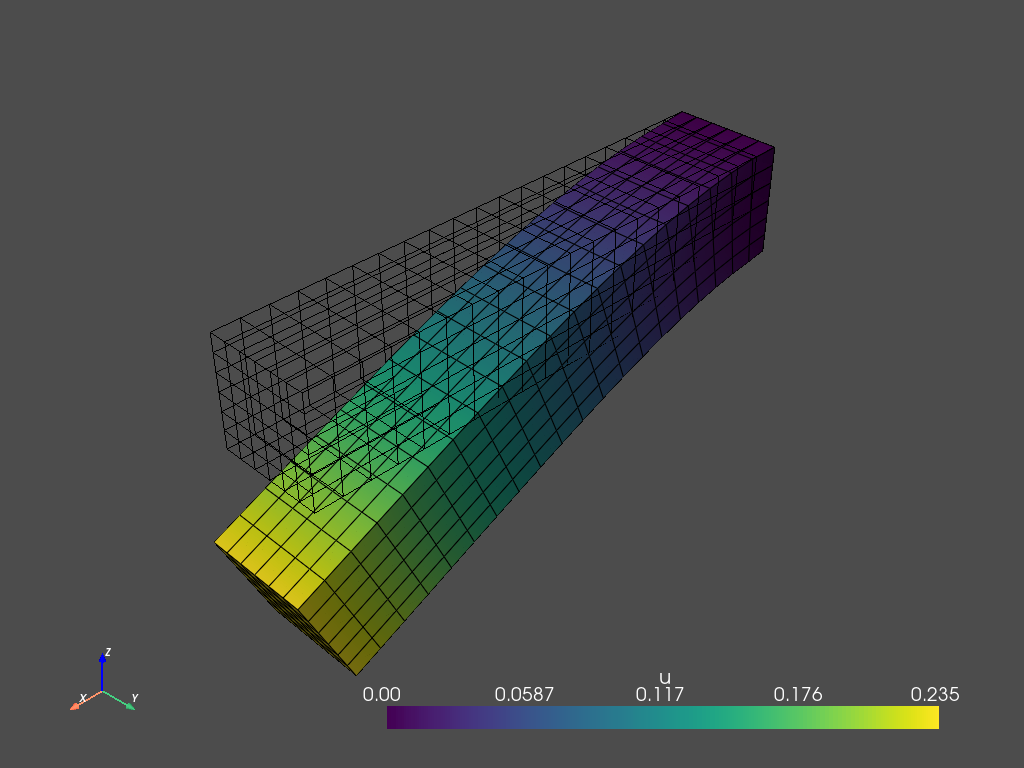

In [9]:
import pyvista
pyvista.start_xvfb()

# Create plotter and pyvista grid
p = pyvista.Plotter()
topology, cell_types, geometry = plot.create_vtk_mesh(V)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

# Attach vector values to grid and warp grid by vector
grid["u"] = uh.x.array.reshape((geometry.shape[0], 3))
actor_0 = p.add_mesh(grid, style="wireframe", color="k")
warped = grid.warp_by_vector("u", factor=1.5)
actor_1 = p.add_mesh(warped, show_edges=True)
p.show_axes()
if not pyvista.OFF_SCREEN:
   p.show()
else:
   figure_as_array = p.screenshot("deflection.png")

También podríamos usar Paraview para visualizar esto.
Como se explicó en secciones anteriores, guardamos la solución con `XDMFFile`.
Después de abrir el archivo `deformation.xdmf` en Paraview y presionar `Apply`, uno puede presionar el botón `Warp by vector` o pasar por el menú superior (`Filters->Alphabetical ->Warp by Vector`) y presione `Apply`. También podemos cambiar el color de la viga deformada cambiando el valor en el menú de color de `Color sólido` a `Deformación`.

In [10]:
with io.XDMFFile(domain.comm, "deformation.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    uh.name = "Deformation"
    xdmf.write_function(uh)

## Cálculo de estrés
Tan pronto como se calcula el desplazamiento, podemos calcular varias medidas de tensión. Calcularemos la tensión de von Mises definida como $\sigma_m=\sqrt{\frac{3}{2}s:s}$ donde $s$ es el tensor de tensión desviador $s(u)=\sigma(u)- \frac{1}{3}\mathrm{tr}(\sigma(u))I$.

In [11]:
s = sigma(uh) -1./3*ufl.tr(sigma(uh))*ufl.Identity(len(uh))
von_Mises = ufl.sqrt(3./2*ufl.inner(s, s))

La variable `von_Mises` ahora es una expresión que debe proyectarse en un espacio funcional apropiado para que podamos visualizarla. Como `uh` es una combinación lineal de funciones continuas por partes de primer orden, las tensiones de von Mises serán una función constante por celdas.

In [12]:
V_von_mises = fem.FunctionSpace(domain, ("DG", 0))
stress_expr = fem.Expression(von_Mises, V_von_mises.element.interpolation_points())
stresses = fem.Function(V_von_mises)
stresses.interpolate(stress_expr)

En las secciones anteriores, solo hemos visualizado funciones Lagrangianas de primer orden. Sin embargo, las tensiones de Von Mises son constantes por tramos en cada celda. Por lo tanto, modificamos ligeramente nuestra rutina de trazado. Lo primero que notamos es que ahora establecemos valores para cada celda, que tiene una correspondencia uno a uno con los grados de libertad en el espacio de funciones.

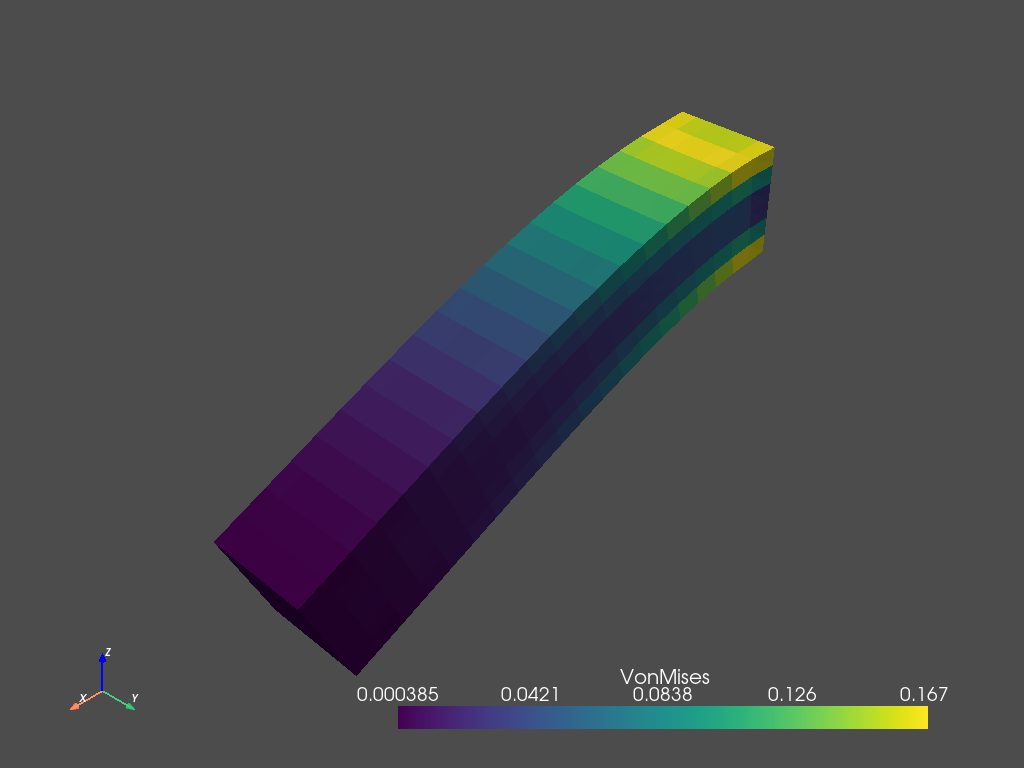

In [13]:
warped.cell_data["VonMises"] = stresses.vector.array
warped.set_active_scalars("VonMises")
p = pyvista.Plotter()
p.add_mesh(warped)
p.show_axes()
if not pyvista.OFF_SCREEN:
   p.show()
else:
   stress_figure = p.screenshot(f"stresses.png")